# Polynomial Regression - Basic Example

Polynomial regression is a form of regression analysis in which the relationship between the independent variable $x$ and the dependent variable $y$ is modeled as an $n$-th degree polynomial.

While it models a non-linear relationship, it is still considered a form of multiple linear regression because the equation is linear in the coefficients. It is often used when a simple linear model doesn't adequately capture the underlying trend of the data.

Intercept (β0): 410.1387428166844
Coefficients (β1, β2): [-34.05739846   0.81019716]

MSE: 51.60601082505018
RMSE: 7.183732374264104
R² Score: 0.9965598286230885


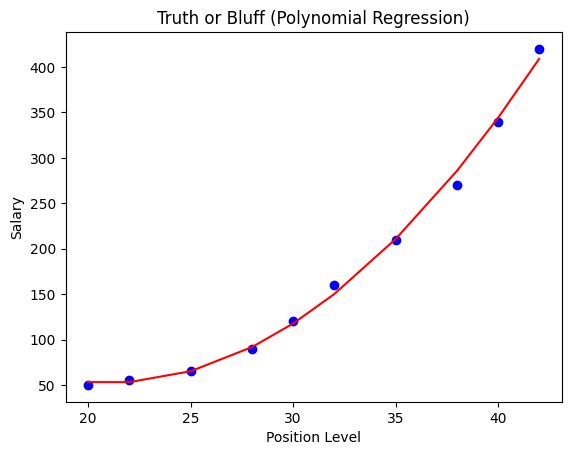

In [2]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Dataset (from your notebook)
X = np.array([20, 22, 25, 28, 30, 32, 35, 38, 40, 42]).reshape(-1, 1)
y = np.array([50, 55, 65, 90, 120, 160, 210, 270, 340, 420])

# Step 3: Polynomial Feature Transformation (degree = 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Step 4: Train Model
model = LinearRegression()
model.fit(X_poly, y)

# Step 5: Predictions
y_pred = model.predict(X_poly)

# Step 6: Coefficients (Betas)
print("Intercept (β0):", model.intercept_)
print("Coefficients (β1, β2):", model.coef_[1:])

# Step 7: Evaluation
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("\nMSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

# Step 8: Visualization
plt.scatter(X, y, color='blue', label='Actual Data')

# Smooth curve
# Plotting the polynomial curve using the trained model
plt.plot(X, y_pred, color = 'red')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

# Polynomial Regression - From a dataset

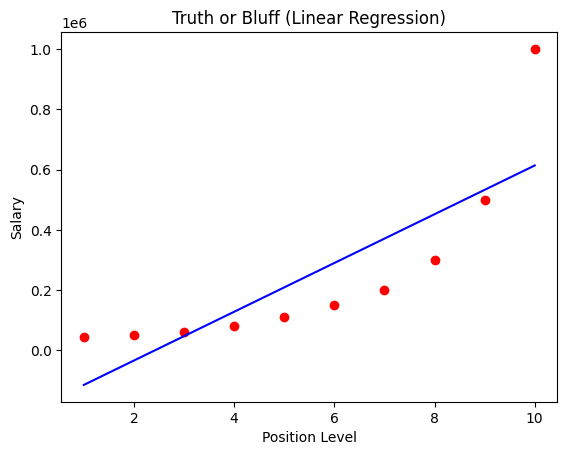

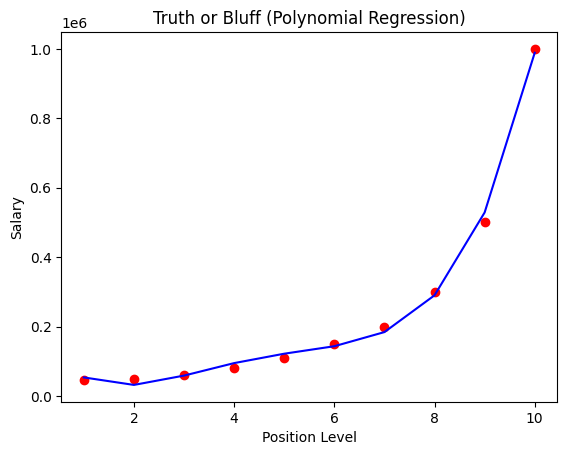

array([158862.45265155])

In [6]:
import numpy as np # Used for working with arrays
import matplotlib.pyplot as plt # Used for plotting graphs
import pandas as pd # Used for importing the data set
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

dataset = pd.read_csv('Position_Salaries.csv') # Importing the CSV file
X = dataset.iloc[:, 1:-1].values # Taking Level as the independent variable
y = dataset.iloc[:, -1].values # Taking Salary as the dependent variable

lin_reg = LinearRegression()
lin_reg.fit(X, y) # Training the linear model on the data

poly_reg = PolynomialFeatures(degree = 4) # Degree can be adjusted; 4 was used for better results
X_poly = poly_reg.fit_transform(X) # Transforming X into polynomial features

lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y) # Training the polynomial model

plt.scatter(X, y, color = 'red') # Plotting actual data points
plt.plot(X, lin_reg.predict(X), color = 'blue') # Plotting the regression line
plt.title('Truth or Bluff (Linear Regression)') # Adding a title
plt.xlabel('Position Level') # Labeling X-axis
plt.ylabel('Salary') # Labeling Y-axis
plt.show()

plt.scatter(X, y, color = 'red')
# Plotting the polynomial curve using the trained model
plt.plot(X, lin_reg_2.predict(X_poly), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

lin_reg.predict([[6.5]]) # Predicting salary for level 6.5 using linear regression

lin_reg_2.predict(poly_reg.fit_transform([[6.5]]))


# Polynomial Regression - Multiple Degrees Comparision

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import math

In [8]:
# Generating a synthetic dataset that mimics 'Position Salaries'
data = {
    'Level': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary': [45000, 50000, 60000, 80000, 110000, 150000, 200000, 300000, 500000, 1000000]
}
df = pd.DataFrame(data)

print("Synthetic Dataset created:")

df

Synthetic Dataset created:


,Level,Salary
0,1,45000
1,2,50000
2,3,60000
3,4,80000
4,5,110000
5,6,150000
6,7,200000
7,8,300000
8,9,500000
9,10,1000000


In [9]:
print("\nDataFrame Info:")
df.info()

print("\nDataFrame Description:")
display(df.describe())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Level   10 non-null     int64
 1   Salary  10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes

DataFrame Description:


,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


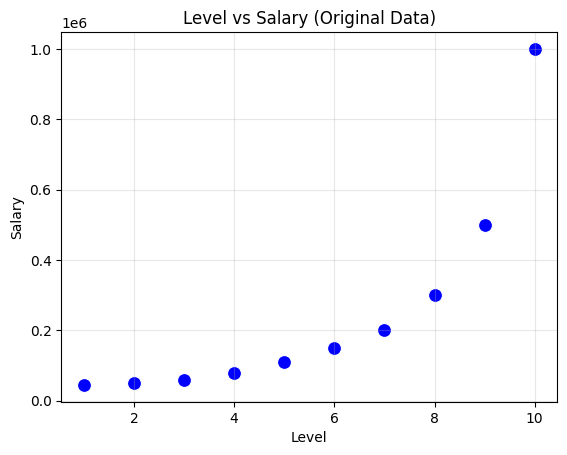

In [10]:
sns.scatterplot(x='Level', y='Salary', data=df, s=100, color='blue')
plt.title('Level vs Salary (Original Data)')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.grid(True, alpha=0.3)
plt.show()

The scatter plot clearly shows a non-linear relationship between 'Level' and 'Salary', suggesting that a linear regression model might not be the best fit. This is a good candidate for Polynomial Regression.

In [ ]:
# Prepare data for modeling
X = df[['Level']].values
y = df['Salary'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Store results for comparison
results = []
predictions_dict = {}

degrees = [1, 2, 3, 4] # Experiment with different polynomial degrees

X_poly_train = None

for degree in degrees:
    print(f"\n--- Training with Degree {degree} ---")

    # Transform features to polynomial features
    poly_features = PolynomialFeatures(degree=degree)
    X_poly_train = poly_features.fit_transform(X_train)
    X_poly_test = poly_features.transform(X_test)

    # Train a Linear Regression model on the polynomial features
    model = LinearRegression()
    model.fit(X_poly_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_poly_test)
    predictions_dict[degree] = model.predict(poly_features.transform(X)) # Predictions for plotting on full range

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Adjusted R-squared calculation
    n = len(y_test) # number of observations
    p = degree + 1 # number of predictors (including intercept and polynomial terms)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    results.append({
        'Degree': degree,
        'MSE': mse,
        'RMSE': rmse,
        'R-squared': r2,
        'Adjusted R-squared': adj_r2
    })

    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R-squared: {r2:.4f}")
    print(f"  Adjusted R-squared: {adj_r2:.4f}")


--- Training with Degree 1 ---
  MSE: 7840057409.33
  RMSE: 88544.10
  R-squared: 0.8451
  Adjusted R-squared: 1.1549

--- Training with Degree 2 ---
  MSE: 11813379747.92
  RMSE: 108689.37
  R-squared: 0.7666
  Adjusted R-squared: 1.1167

--- Training with Degree 3 ---
  MSE: 6263853282.86
  RMSE: 79144.51
  R-squared: 0.8763
  Adjusted R-squared: 1.0412

--- Training with Degree 4 ---
  MSE: 1444499305.55
  RMSE: 38006.57
  R-squared: 0.9715
  Adjusted R-squared: 1.0071


## Multiple Degree Comparison Graph

Let's visualize how models with different polynomial degrees fit the original data.

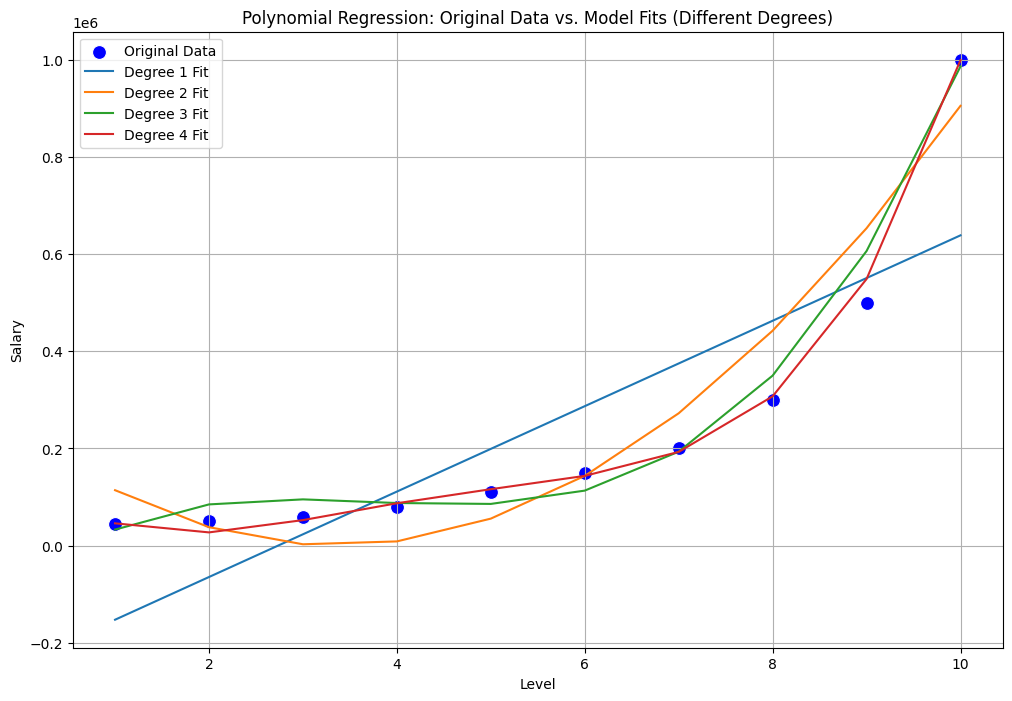

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Level', y='Salary', data=df, s=100, color='blue', label='Original Data')

for degree in degrees:
    plt.plot(X, predictions_dict[degree], label=f'Degree {degree} Fit')

plt.title('Polynomial Regression: Original Data vs. Model Fits (Different Degrees)')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

## Evaluation Metrics Comparison

Now, let's compare the performance metrics for each polynomial degree.

In [ ]:
metrics_df = pd.DataFrame(results)
print("\nModel Evaluation Metrics:")
display(metrics_df.set_index('Degree'))


Model Evaluation Metrics:


,MSE,RMSE,R-squared,Adjusted R-squared
Degree,,,,
1,7.840057e+09,88544.098670,0.845135,1.154865
2,1.181338e+10,108689.372746,0.766649,1.116675
3,6.263853e+09,79144.508861,0.876270,1.041243
4,1.444499e+09,38006.569242,0.971467,1.007133


## 7. Conclusion

From the comparison, we can observe the following:

*   **Degree 1 (Linear Regression)**: As expected, a linear model doesn't capture the non-linear trend well, resulting in relatively high MSE/RMSE and lower R-squared/Adjusted R-squared.
*   **Increasing Degrees**: As the polynomial degree increases, the model generally fits the training data better, leading to lower error metrics and higher R-squared values.
*   **Overfitting**: While higher degrees might yield better metrics on the training data, they can lead to overfitting, especially if the underlying relationship isn't truly that complex. The Adjusted R-squared helps to penalize models with too many features, giving a more realistic view of model performance on unseen data.

In this specific synthetic example, a degree 3 or 4 polynomial seems to fit the data very well, indicated by the high R-squared and visually close fit to the data points. Choosing the optimal degree often involves balancing model complexity with performance on new, unseen data, often using techniques like cross-validation.